In [105]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot, shapiro, normaltest, kstest, skew, kurtosis

## Why It's So Important

| Reason | Explanation |
| :--- | :--- |
| **Central Limit Theorem** | Averages of **ANY** distribution become Normal |
| **MSE Loss** | Linear regression assumes Normal errors |
| **Maximum Entropy** | Most "natural" distribution for continuous data |
| **Computational ease** | Beautiful mathematical properties |
| **Ubiquity** | Heights, weights, test scores, measurement errors |

## What is the 68-95-99.7 Rule (Empirical Rule)?

The **Empirical Rule** (also called the **68-95-99.7 Rule**) is a quick shortcut that tells you how data is spread out in a **normal distribution** (bell curve).

It says that if your data follows a normal distribution:

- **68%** of the data falls within **1 standard deviation** of the mean
- **95%** of the data falls within **2 standard deviations** of the mean
- **99.7%** of the data falls within **3 standard deviations** of the mean

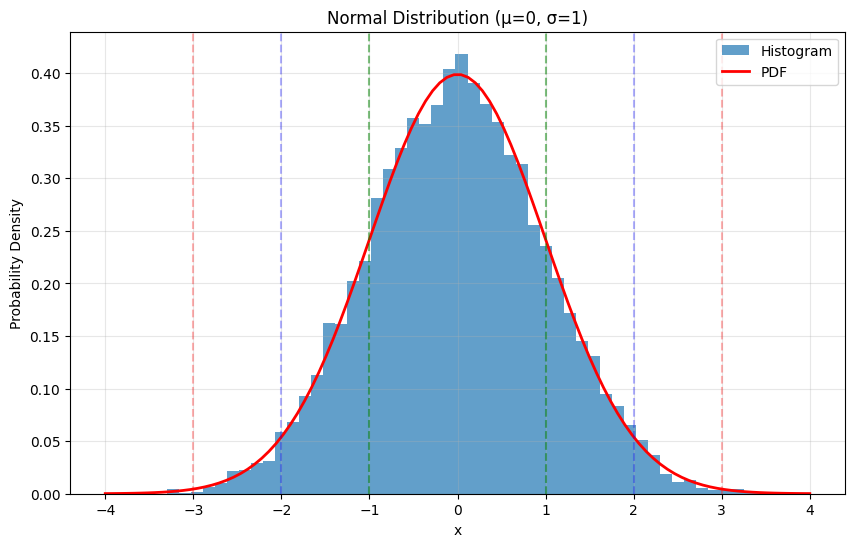

Within 1σ: 0.681
Within 2σ: 0.956
Within 3σ: 0.998


In [28]:
# Standard Normal
mu, sigma = 0, 1  

# Normal Dataset
samples = np.random.normal(mu, sigma, 10000)

# Plot histogram and PDF
plt.figure(figsize=(10, 6))
plt.hist(samples, bins=50, density=True, alpha=0.7, label='Histogram')

# PDF
x = np.linspace(-4, 4, 100)
pdf = norm.pdf(x, mu, sigma)
plt.plot(x, pdf, 'r-', linewidth=2, label='PDF')

# Show 68-95-99.7 rule
plt.axvline(mu - 1*sigma, color='green', linestyle='--', alpha=0.5)
plt.axvline(mu + 1*sigma, color='green', linestyle='--', alpha=0.5)
plt.axvline(mu - 2*sigma, color='blue', linestyle='--', alpha=0.3)
plt.axvline(mu + 2*sigma, color='blue', linestyle='--', alpha=0.3)
plt.axvline(mu - 3*sigma, color='red', linestyle='--', alpha=0.3)
plt.axvline(mu + 3*sigma, color='red', linestyle='--', alpha=0.3)

plt.title(f'Normal Distribution (μ={mu}, σ={sigma})')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Verify 68-95-99.7 rule
within_1sigma = np.sum(np.abs(samples - mu) < sigma) / len(samples)
within_2sigma = np.sum(np.abs(samples - mu) < 2*sigma) / len(samples)
within_3sigma = np.sum(np.abs(samples - mu) < 3*sigma) / len(samples)

print(f"Within 1σ: {within_1sigma:.3f}")
print(f"Within 2σ: {within_2sigma:.3f}")
print(f"Within 3σ: {within_3sigma:.3f}")

## The Central Limit Theorem

If you take sufficiently large random samples from any population (with a finite level of variance), the distribution of the sample averages will be approximately normally distributed (a bell curve), regardless of the original population's distribution.

Imagine you want to know the average age of everyone in a very large city.

Step 1: Instead of asking everyone, you take a random sample of 50 people and calculate their average age.

Step 2: You put that sample back, take another random sample of 50 different people, and calculate their average age.

Step 3: You do this 1,000 times.

The CLT says: If you plot a histogram of those 1,000 averages, that histogram will look like a perfect bell curve (normal distribution).

Sample Shape:  (100, 50)


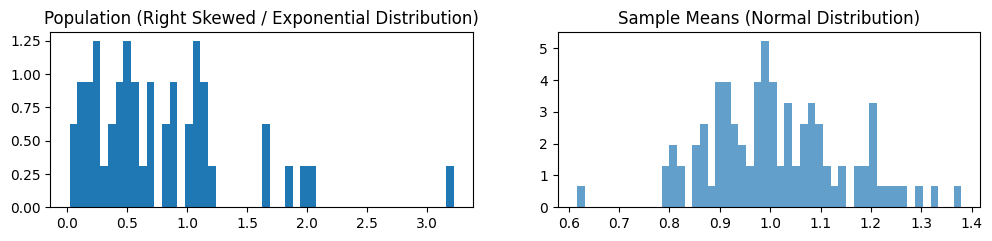

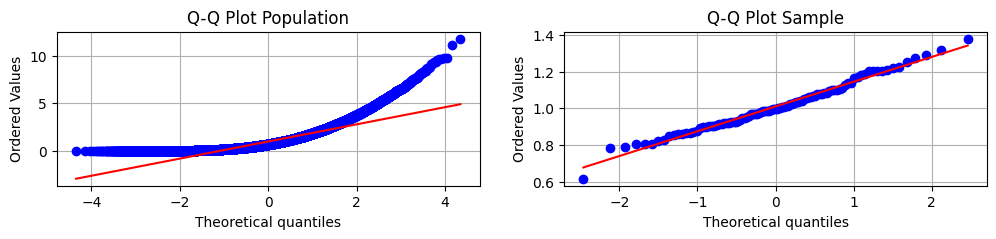

In [84]:
# Create population (Exponential Distribution)
population = np.random.exponential(size=100000)

plt.figure(figsize=(12, 5))

# plot population
plt.subplot(2, 2, 1)
plt.hist(sample, bins=50, density=True)
plt.title('Population (Right Skewed / Exponential Distribution)')

# 100 Sample, each of size 50
samples_list = list()
for i in range(100):
    sample = np.random.choice(population, size=50)
    samples_list.append(sample)

samples = np.array(samples_list)
print('Sample Shape: ', samples.shape)

# sample means are supposed to be Normal
sample_means = np.mean(samples, axis=1)

# plot sample
plt.subplot(2, 2, 2)
plt.hist(sample_means, bins=50, density=True, alpha=0.7)
plt.title('Sample Means (Normal Distribution)')
plt.show()

# plot Q-Q

plt.figure(figsize=(12, 2))
plt.subplot(1, 2, 1)
probplot(population, dist="norm", plot=plt)
plt.title("Q-Q Plot Population")
plt.grid(True)

plt.subplot(1, 2, 2)
probplot(sample_means, dist="norm", plot=plt)
plt.title("Q-Q Plot Sample")
plt.grid(True)

plt.show()

## How to know if data follows normal distribution or not!

When to Use Which Test

| Test | Best For | Sample Size | Pros | Cons |
| :--- | :--- | :--- | :--- | :--- |
| **Shapiro-Wilk** | General | n ≤ 5000 | Most powerful | Slower for huge data |
| **D'Agostino** | General | Any | Fast, robust | Less powerful than Shapiro |
| **Kolmogorov-Smirnov** | Large n | Any | Non-parametric | Less sensitive at tails |
| **Anderson-Darling** | Tails matter | Any | Good for tails | Complex |
| **Q-Q Plot** | Visual | Any | Intuitive | Subjective |
| **Skewness/Kurtosis** | Quick check | Any | Fast | Rules of thumb only |

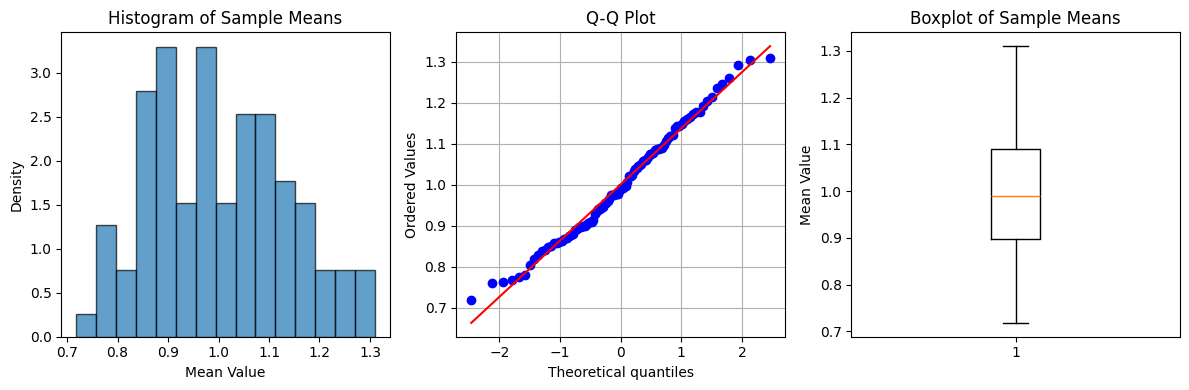

In [83]:
# ============================================
# METHOD 1: Visual Checks
# ============================================

# 1. Histogram with KDE (Kernel Density Estimate)
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(sample_means, bins=15, density=True, edgecolor='black', alpha=0.7)
plt.title("Histogram of Sample Means")
plt.xlabel("Mean Value")
plt.ylabel("Density")

# 2. Q-Q Plot (Quantile-Quantile Plot)
plt.subplot(1, 3, 2)
probplot(sample_means, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.grid(True)

# 3. Boxplot
plt.subplot(1, 3, 3)
plt.boxplot(sample_means, vert=True)
plt.title("Boxplot of Sample Means")
plt.ylabel("Mean Value")

plt.tight_layout()
plt.show()

In [97]:
# ============================================
# METHOD 2: Statistical Tests
# ============================================

# 1. Shapiro-Wilk Test (Best for small samples, n < 5000)
shapiro_stat, shapiro_p = shapiro(sample_means)
print("Shapiro-Wilk Test:")
print(f"  Test Statistic: {shapiro_stat:.4f}")
print(f"  P-value: {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("  Normal (p > 0.05)")
else:
    print("  Not Normal (p <= 0.05)")


# 2. D'Agostino-Pearson Test (Tests skewness and kurtosis)
dagostino_stat, dagostino_p = normaltest(sample_means)
print("D'Agostino-Pearson Test:")
print(f"  Test Statistic: {dagostino_stat:.4f}")
print(f"  P-value: {dagostino_p:.4f}")

if dagostino_p > 0.05:
    print("  Normal (p > 0.05)")
else:
    print("  Not Normal (p <= 0.05)")

# 3. Kolmogorov-Smirnov Test (Compares to normal distribution)
# You need to estimate mean and std from data
mu, sigma = np.mean(sample_means), np.std(sample_means)
ks_stat, ks_p = kstest(sample_means, 'norm', args=(mu, sigma))
print("Kolmogorov-Smirnov Test:")
print(f"  Test Statistic: {ks_stat:.4f}")
print(f"  P-value: {ks_p:.4f}")

if ks_p > 0.05:
    print("  Normal (p > 0.05)")
else:
    print("  Not Normal (p <= 0.05)")

Shapiro-Wilk Test:
  Test Statistic: 0.9865
  P-value: 0.4046
  Normal (p > 0.05)
D'Agostino-Pearson Test:
  Test Statistic: 1.5983
  P-value: 0.4497
  Normal (p > 0.05)
Kolmogorov-Smirnov Test:
  Test Statistic: 0.0670
  P-value: 0.7352
  Normal (p > 0.05)


In [111]:
# ============================================
# METHOD 3: Numerical Summary Statistics
# ============================================

# Calculate skewness and kurtosis (between -0.5 and 0.5 means normal distribution / approximately symmetric)
skewness_ = skew(sample_means)
kurtosis_ = kurtosis(sample_means)  # Fisher's definition (0 = normal)

print("Numerical Summary:")
print(f"  Skewness: {skewness_:.4f} (should be close to 0)")
print(f"  Kurtosis: {kurtosis_:.4f} (should be close to 0)")

if abs(skewness_) < 0.5:
    print("  Skewness is within acceptable range")
else:
    print("  Skewness may indicate non-normality")

if abs(kurtosis_) < 0.5:
    print("  Kurtosis is within acceptable range")
else:
    print("  Kurtosis may indicate non-normality")


Numerical Summary:
  Skewness: 0.2501 (should be close to 0)
  Kurtosis: 0.1678 (should be close to 0)
  Skewness is within acceptable range
  Kurtosis is within acceptable range


In [108]:
# ============================================
# METHOD 5: Calculate Confidence Intervals
# ============================================

# Imperical rule check
mean_val = np.mean(sample_means)
std_val = np.std(sample_means)

within_1sigma = np.sum(np.abs(sample_means - mean_val) <= std_val) / len(sample_means) * 100
within_2sigma = np.sum(np.abs(sample_means - mean_val) <= 2*std_val) / len(sample_means) * 100
within_3sigma = np.sum(np.abs(sample_means - mean_val) <= 3*std_val) / len(sample_means) * 100

print("Empirical Rule Check:")
print(f"  Within 1σ: {within_1sigma:.1f}% (expected ~68%)")
print(f"  Within 2σ: {within_2sigma:.1f}% (expected ~95%)")
print(f"  Within 3σ: {within_3sigma:.1f}% (expected ~99.7%)")

if 65 < within_1sigma < 71:
    print("  1σ matches 68-95-99.7 rule")
else:
    print("  1σ deviates from 68-95-99.7 rule")

if 93 < within_2sigma < 97:
    print("  2σ matches 68-95-99.7 rule")
else:
    print("  2σ deviates from 68-95-99.7 rule")

Empirical Rule Check:
  Within 1σ: 68.0% (expected ~68%)
  Within 2σ: 96.0% (expected ~95%)
  Within 3σ: 100.0% (expected ~99.7%)
  1σ matches 68-95-99.7 rule
  2σ matches 68-95-99.7 rule


## MSE Loss = Normal Assumption

If your residuals are NOT Normal (e.g., skewed, heavy-tailed), your linear regression model is misspecified. You might need to:

Transform your target variable (e.g., log transform)

Use a different loss function

Use a different model (e.g., robust regression)

## Feature Scaling

Normal distribution explains why we standardize features

## Normal Distribution in ML

| ML Component | Normal Distribution Connection |
| :--- | :--- |
| **Linear Regression** | Assumes Normal errors (MSE loss) |
| **Gaussian Naive Bayes** | Features are Normal per class |
| **Gaussian Process** | Defines distribution over functions |
| **PCA/SVD** | Assumes Normal data for optimality |
| **Feature Standardization** | Transforms to Normal(0,1) |
| **Confidence Intervals** | Based on Normal assumption |
| **Gradient Descent** | Converges faster with Normal features |
| **Regularization (L2)** | Equivalent to Normal prior (MAP) |